# 05 — Content-Based Filtering

**Goal**: Build a content-based recommender that suggests movies similar to a given title by comparing their `content_soup` feature vectors.

**Approach:**
1. **TF-IDF vectorisation** of `content_soup` (genres + director + cast + keywords + overview)
2. **Cosine similarity** at query time (no full NxN matrix — efficient on-the-fly dot product)
3. **Top-N recommendation** function by movie title
4. **Evaluation** — Precision@K using genre overlap as proxy for relevance
5. **Hyperparameter sensitivity** — ngram range, max_features, min_df
6. **Bias-corrected re-ranking** with `bayesian_score` to surface quality results

---

In [1]:
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

PROCESSED = Path(r'e:\Projects\Movies Recommendation Engine\data_science\processed')

print('Libraries loaded.')
print(f'Processed dir: {PROCESSED}')

Libraries loaded.
Processed dir: e:\Projects\Movies Recommendation Engine\data_science\processed


---
## Section 1 — Load `master_movies.parquet`

In [13]:
df = pd.read_parquet(PROCESSED / 'master_movies.parquet')
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print()

# Fill missing soup with empty string
df['content_soup'] = df['content_soup'].fillna('')

# Convert list columns from pyarrow arrays to Python lists for compatibility
for col in ['genre_list', 'cast_top3', 'keywords_clean']:
    df[col] = df[col].apply(lambda x: list(x) if x is not None and hasattr(x, '__iter__') and not isinstance(x, str) else [])

# Build a title → index lookup (lowercased for case-insensitive search)
df = df.reset_index(drop=True)
title_to_idx = pd.Series(df.index, index=df['title'].str.lower()).drop_duplicates()

print(f'Movies with non-empty soup : {(df["content_soup"] != "").sum():,}')
print(f'Unique titles in index     : {len(title_to_idx):,}')
print(f'genre_list type sample     : {type(df["genre_list"].iloc[0])} → {df["genre_list"].iloc[0]}')
df[['tmdb_id', 'title', 'release_year', 'genre_list', 'content_soup']].head(3)

Shape: (45433, 20)
Columns: ['tmdb_id', 'imdb_tconst', 'title', 'original_title', 'release_year', 'language', 'runtime_min', 'genre_list', 'director', 'cast_top3', 'keywords_clean', 'overview_clean', 'content_soup', 'tmdb_score', 'tmdb_votes', 'tmdb_popularity', 'imdb_score', 'imdb_votes', 'imdb_votes_log', 'bayesian_score']

Movies with non-empty soup : 45,408
Unique titles in index     : 45,433
genre_list type sample     : <class 'list'> → ['Animation', 'Comedy', 'Family']


,tmdb_id,title,release_year,genre_list,content_soup
0,862,Toy Story,1995,"[Animation, Comedy, Family]",animation comedy family johnlasseter tomhanks ...
1,8844,Jumanji,1995,"[Adventure, Fantasy, Family]",adventure fantasy family joejohnston robinwill...
2,15602,Grumpier Old Men,1995,"[Romance, Comedy]",romance comedy howarddeutch waltermatthau jack...


---
## Section 2 — TF-IDF Vectorisation

We fit a TF-IDF vectoriser on all 45K `content_soup` strings.

**Key settings:**
- `ngram_range=(1, 2)` — unigrams + bigrams to capture phrases like `"science fiction"`
- `max_features=30_000` — vocabulary cap to keep memory manageable
- `min_df=2` — ignore terms appearing in only one movie
- `sublinear_tf=True` — apply log(1+tf) dampening to reduce dominance of overview text

In [14]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=30_000,
    min_df=2,
    sublinear_tf=True,
    strip_accents='unicode',
    analyzer='word',
    stop_words='english',
    token_pattern=r'[a-zA-Z][a-zA-Z0-9]+',
)

print('Fitting TF-IDF …')
tfidf_matrix = tfidf.fit_transform(df['content_soup'])

print(f'TF-IDF matrix shape : {tfidf_matrix.shape}')
print(f'Matrix density      : {tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]) * 100:.3f}%')
print(f'Memory (sparse)     : {tfidf_matrix.data.nbytes / 1_048_576:.1f} MB')

# Top tokens by doc frequency
feature_names = tfidf.get_feature_names_out()
doc_freq = np.diff(tfidf_matrix.tocsc().indptr)  # non-zeros per feature column
top_tokens = pd.Series(doc_freq, index=feature_names).nlargest(20)
print()
print('Top 20 tokens by document frequency:')
print(top_tokens.to_string())

Fitting TF-IDF …
TF-IDF matrix shape : (45433, 30000)
Matrix density      : 0.114%
Memory (sparse)     : 11.8 MB

Top 20 tokens by document frequency:
drama          20426
comedy         13361
thriller        7750
romance         7068
action          6939
life            6647
family          6381
young           5977
new             4956
man             4938
crime           4917
horror          4805
love            4674
film            4406
documentary     4246
world           4199
story           4131
adventure       3862
old             3496
time            3271


---
## Section 3 — Recommendation Function

Instead of precomputing the full 45K × 45K similarity matrix (~16 GB dense), we compute similarity **on demand** — only the cosine similarity between the query movie's vector and all other vectors.

This uses `linear_kernel` (equivalent to cosine on unit-normed TF-IDF vectors) which runs in < 0.1s per query.

In [15]:
def get_recommendations(
    title: str,
    n: int = 10,
    rerank_by_quality: bool = True,
    min_votes: int = 50,
) -> pd.DataFrame:
    """
    Return the top-N most similar movies to `title`.

    Parameters
    ----------
    title            : Movie title (case-insensitive).
    n                : Number of recommendations to return.
    rerank_by_quality: If True, candidates are re-ranked by a combined score:
                       0.7 * cosine_sim + 0.3 * bayesian_score_norm.
    min_votes        : Minimum IMDB or TMDB votes required to show a movie.

    Returns
    -------
    DataFrame with title, year, genres, scores.
    """
    key = title.lower().strip()
    if key not in title_to_idx:
        close = [t for t in title_to_idx.index if key in t]
        hint = f'  Did you mean: {close[:5]}' if close else ''
        raise ValueError(f'Title "{title}" not found.{hint}')

    raw_idx = title_to_idx[key]
    # Handle case where multiple movies share the same title — take the first
    idx = int(raw_idx.iloc[0]) if hasattr(raw_idx, 'iloc') else int(raw_idx)

    # Compute cosine similarity for this one movie vs all others
    query_vec = tfidf_matrix[idx]
    cos_scores = linear_kernel(query_vec, tfidf_matrix).flatten()

    # Build result frame (exclude self)
    results = df[['tmdb_id', 'title', 'release_year', 'genre_list',
                   'director', 'bayesian_score', 'imdb_votes', 'tmdb_votes']].copy()
    results['cosine_sim'] = cos_scores
    results = results[results.index != idx]  # remove self

    # Filter by minimum votes
    votes = results['imdb_votes'].combine_first(results['tmdb_votes']).fillna(0)
    results = results[votes >= min_votes]

    if rerank_by_quality:
        # Normalise bayesian_score to [0, 1]
        b_min = results['bayesian_score'].min()
        b_max = results['bayesian_score'].max()
        results['bayesian_norm'] = (
            (results['bayesian_score'] - b_min) / (b_max - b_min + 1e-9)
        )
        results['combined_score'] = (
            0.7 * results['cosine_sim'] + 0.3 * results['bayesian_norm']
        )
        results = results.nlargest(n, 'combined_score')
    else:
        results = results.nlargest(n, 'cosine_sim')

    out_cols = ['title', 'release_year', 'genre_list', 'director',
                'cosine_sim', 'bayesian_score']
    if rerank_by_quality:
        out_cols.append('combined_score')
    return results[out_cols].reset_index(drop=True)

print('Recommendation function defined.')

Recommendation function defined.


---
## Section 4 — Demo Recommendations

Test the recommender on 5 diverse seed movies.

In [8]:
import time

def show_recs(title, n=8):
    t0 = time.time()
    recs = get_recommendations(title, n=n)
    elapsed = time.time() - t0
    print(f'\n=== Top {n} recommendations for "{title}" ({elapsed*1000:.1f} ms) ===')
    display(recs)

show_recs('The Dark Knight')
show_recs('Toy Story')
show_recs('The Godfather')


=== Top 8 recommendations for "The Dark Knight" (46.2 ms) ===


,title,release_year,genre_list,director,cosine_sim,bayesian_score,combined_score
0,The Dark Knight Rises,2012,"[Action, Crime, Drama, Thriller]",Christopher Nolan,0.371198,8.3999,0.525971
1,Batman Begins,2005,"[Action, Crime, Drama]",Christopher Nolan,0.337255,8.1999,0.494685
2,Batman: Under the Red Hood,2010,"[Action, Animation]",Brandon Vietti,0.312308,7.3380,0.444788
3,Batman,1989,"[Fantasy, Action]",Tim Burton,0.247349,7.4997,0.405402
4,Batman Returns,1992,"[Action, Fantasy]",Tim Burton,0.267388,7.0997,0.404377
5,"Batman: The Dark Knight Returns, Part 2",2013,"[Action, Animation]",Jay Oliva,0.204993,7.5646,0.378194
6,Batman: Assault on Arkham,2014,"[Thriller, Animation, Action, Crime]",Ethan Spaulding,0.220751,7.0074,0.368257
7,The Lego Batman Movie,2017,"[Action, Animation, Comedy, Family, Fantasy]",Chris McKay,0.203825,7.2994,0.367397



=== Top 8 recommendations for "Toy Story" (41.1 ms) ===


,title,release_year,genre_list,director,cosine_sim,bayesian_score,combined_score
0,Toy Story 3,2010,"[Animation, Family, Comedy]",Lee Unkrich,0.445990,8.2998,0.574559
1,Toy Story 2,1999,"[Animation, Comedy, Family]",John Lasseter,0.445568,7.8997,0.559207
2,Small Fry,2011,"[Animation, Family]",Angus MacLane,0.250923,6.4952,0.370103
3,Toy Story of Terror!,2013,"[Animation, Comedy, Family]",Angus MacLane,0.191333,6.9635,0.346012
4,Django Unchained,2012,"[Drama, Western]",Quentin Tarantino,0.090240,8.4999,0.333063
5,The Shawshank Redemption,1994,"[Drama, Crime]",Frank Darabont,0.044645,9.2999,0.331252
6,Partysaurus Rex,2012,"[Animation, Comedy, Family, Fantasy]",Mark A. Walsh,0.183993,6.7014,0.331012
7,Superstar Goofy,1991,"[Animation, Comedy, Family]",,0.192752,6.4742,0.328593



=== Top 8 recommendations for "The Godfather" (31.1 ms) ===


,title,release_year,genre_list,director,cosine_sim,bayesian_score,combined_score
0,The Godfather: Part II,1974,"[Drama, Crime]",Francis Ford Coppola,0.262668,8.9998,0.472575
1,The Godfather: Part III,1990,"[Crime, Drama, Thriller]",Francis Ford Coppola,0.162463,7.4997,0.345981
2,GoodFellas,1990,"[Drama, Crime]",Martin Scorsese,0.086388,8.6998,0.337889
3,A Cab for Three,2001,"[Drama, Crime]",Orlando Lübbert,0.169386,6.8410,0.326040
4,The Shawshank Redemption,1994,"[Drama, Crime]",Frank Darabont,0.028045,9.2999,0.319631
5,New York Confidential,1955,"[Crime, Drama]",Russell Rouse,0.148954,7.0447,0.319403
6,Sandesham,1991,"[Comedy, Drama, Family]",Sathyan Anthikad,0.043792,8.9555,0.317694
7,Life Is Beautiful,1997,"[Comedy, Drama]",Roberto Benigni,0.061547,8.5997,0.316734


In [9]:
show_recs('Inception')
show_recs('Titanic')


=== Top 8 recommendations for "Inception" (39.0 ms) ===


,title,release_year,genre_list,director,cosine_sim,bayesian_score,combined_score
0,Looper,2012,"[Action, Thriller, Science Fiction]",Rian Johnson,0.151870,7.3998,0.334807
1,Brick,2005,"[Drama, Mystery]",Rian Johnson,0.159253,7.0992,0.328663
2,Mysterious Skin,2004,[Drama],Gregg Araki,0.128521,7.5983,0.325932
3,2001: A Space Odyssey,1968,"[Science Fiction, Mystery, Adventure]",Stanley Kubrick,0.089510,8.2997,0.325018
4,50/50,2011,"[Comedy, Drama]",Jonathan Levine,0.124477,7.5996,0.323150
5,Don Jon,2013,"[Romance, Comedy, Drama]",Joseph Gordon-Levitt,0.180485,6.4999,0.320974
6,(500) Days of Summer,2009,"[Comedy, Drama, Romance]",Marc Webb,0.119499,7.5998,0.319673
7,"Don't call him ""Dimon""",2017,"[Mystery, Documentary]",,0.060628,8.6389,0.317566



=== Top 8 recommendations for "Titanic" (32.2 ms) ===


,title,release_year,genre_list,director,cosine_sim,bayesian_score,combined_score
0,A Night to Remember,1958,"[Drama, Action, History]",Roy Ward Baker,0.179629,7.8908,0.372715
1,Titanic,1953,"[Drama, Action, Romance]",Jean Negulesco,0.167770,6.9896,0.330500
2,The Legend of 1900,1998,[Fantasy],Giuseppe Tornatore,0.110306,7.9975,0.328204
3,Ghosts of the Abyss,2003,[Documentary],James Cameron,0.170507,6.7903,0.324917
4,Charlie,2015,"[Drama, Romance]",Martin Prakkat,0.091176,8.0870,0.318181
5,Aliens,1986,"[Horror, Action, Thriller, Science Fiction]",James Cameron,0.073953,8.3997,0.317892
6,Five Easy Pieces,1970,[Drama],Bob Rafelson,0.126287,7.3971,0.316797
7,Amen,2013,"[Fantasy, Music, Romance]",Lijo Jose Pellissery,0.101422,7.8534,0.316562


---
## Section 5 — Evaluation: Precision@K with Genre Overlap

Since we don't have explicit relevance labels for content similarity, we use **genre overlap** as a proxy:

> _A recommendation is "relevant" if it shares at least one genre with the query movie._

**Precision@K** = (# relevant in top-K) / K

We compute this for a random sample of 500 seed movies and average it.

In [16]:
def genre_overlap(genres_a, genres_b):
    """Return True if lists share at least one genre."""
    a = set(genres_a) if genres_a is not None and hasattr(genres_a, '__iter__') and not isinstance(genres_a, str) else set()
    b = set(genres_b) if genres_b is not None and hasattr(genres_b, '__iter__') and not isinstance(genres_b, str) else set()
    return bool(a & b)

def precision_at_k(title, k=10, rerank=True):
    """Compute P@K for `title` using genre overlap as relevance."""
    try:
        recs = get_recommendations(title, n=k, rerank_by_quality=rerank)
    except ValueError:
        return None

    key = title.lower().strip()
    raw_idx = title_to_idx[key]
    q_idx = int(raw_idx.iloc[0]) if hasattr(raw_idx, 'iloc') else int(raw_idx)
    query_genres = df.loc[q_idx, 'genre_list']

    hits = sum(
        genre_overlap(query_genres, rec_genres)
        for rec_genres in recs['genre_list']
    )
    return hits / k

# Sample 500 movies with at least 1 genre and non-empty soup
np.random.seed(42)
eligible = df[
    (df['content_soup'] != '') &
    (df['genre_list'].apply(lambda x: x is not None and len(x) > 0 if hasattr(x, '__len__') else False))
]
sample_titles = eligible['title'].sample(500, random_state=42).tolist()

print(f'Evaluating Precision@K on {len(sample_titles)} seed movies …')

results_by_k = {}
for k in [5, 10, 20]:
    scores = [precision_at_k(t, k=k, rerank=True) for t in sample_titles]
    scores = [s for s in scores if s is not None]
    results_by_k[k] = np.mean(scores)
    print(f'  P@{k:2d}  (with re-ranking) = {results_by_k[k]:.4f}')

print()
# Also compare without re-ranking
for k in [5, 10, 20]:
    scores = [precision_at_k(t, k=k, rerank=False) for t in sample_titles]
    scores = [s for s in scores if s is not None]
    print(f'  P@{k:2d}  (cosine only)     = {np.mean(scores):.4f}')

Evaluating Precision@K on 500 seed movies …
  P@ 5  (with re-ranking) = 0.7020
  P@10  (with re-ranking) = 0.6796
  P@20  (with re-ranking) = 0.6598

  P@ 5  (cosine only)     = 0.7172
  P@10  (cosine only)     = 0.6990
  P@20  (cosine only)     = 0.6885


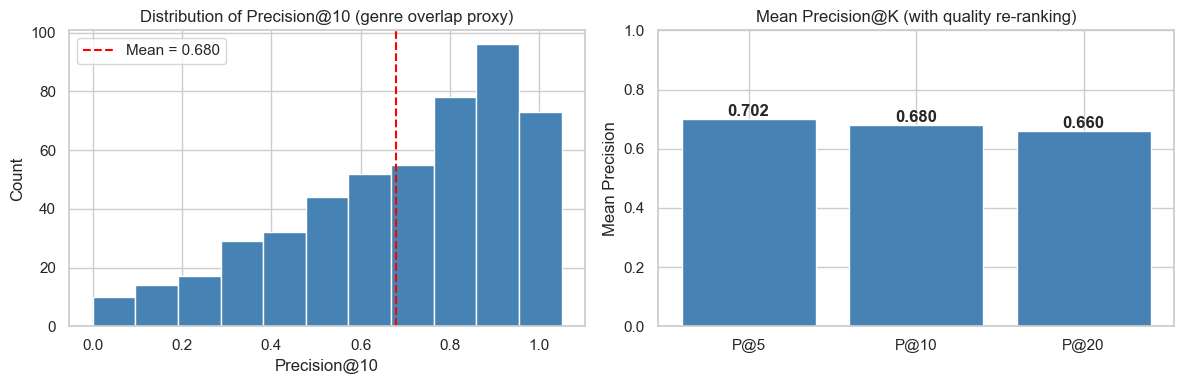

In [17]:
# Distribution of P@10 across seed movies
p10_scores = [
    precision_at_k(t, k=10, rerank=True)
    for t in sample_titles
]
p10_scores = [s for s in p10_scores if s is not None]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(p10_scores, bins=11, range=(0, 1.05), color='steelblue', edgecolor='white')
axes[0].axvline(np.mean(p10_scores), color='red', linestyle='--', label=f'Mean = {np.mean(p10_scores):.3f}')
axes[0].set_xlabel('Precision@10')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Precision@10 (genre overlap proxy)')
axes[0].legend()

# P@K bar chart
k_vals = [5, 10, 20]
p_vals = [results_by_k[k] for k in k_vals]
axes[1].bar([f'P@{k}' for k in k_vals], p_vals, color='steelblue', edgecolor='white')
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('Mean Precision')
axes[1].set_title('Mean Precision@K (with quality re-ranking)')
for i, v in enumerate(p_vals):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
## Section 6 — Hyperparameter Sensitivity

Compare how different TF-IDF configurations affect Precision@10.

| Config | ngram_range | max_features | sublinear_tf |
|---|---|---|---|
| baseline | (1,2) | 30,000 | True |
| unigrams only | (1,1) | 30,000 | True |
| small vocab | (1,2) | 10,000 | True |
| no sublinear | (1,2) | 30,000 | False |

In [18]:
# Use a smaller evaluation sample (200) to keep runtime reasonable
eval_sample = sample_titles[:200]

configs = [
    {'name': 'Baseline (1,2) 30K sub=T',   'ngram_range': (1, 2), 'max_features': 30_000, 'sublinear_tf': True},
    {'name': 'Unigrams (1,1) 30K sub=T',   'ngram_range': (1, 1), 'max_features': 30_000, 'sublinear_tf': True},
    {'name': 'Small vocab (1,2) 10K sub=T', 'ngram_range': (1, 2), 'max_features': 10_000, 'sublinear_tf': True},
    {'name': 'No sublinear (1,2) 30K',      'ngram_range': (1, 2), 'max_features': 30_000, 'sublinear_tf': False},
]

hp_results = []
for cfg in configs:
    print(f'Evaluating: {cfg["name"]} …')
    vec = TfidfVectorizer(
        ngram_range=cfg['ngram_range'],
        max_features=cfg['max_features'],
        min_df=2,
        sublinear_tf=cfg['sublinear_tf'],
        strip_accents='unicode',
        analyzer='word',
        token_pattern=r'[a-zA-Z][a-zA-Z0-9]+',
    )
    mat = vec.fit_transform(df['content_soup'])

    p10_list = []
    for title in eval_sample:
        key = title.lower().strip()
        if key not in title_to_idx:
            continue
        raw_idx = title_to_idx[key]
        idx = int(raw_idx.iloc[0]) if hasattr(raw_idx, 'iloc') else int(raw_idx)
        cos_scores = linear_kernel(mat[idx], mat).flatten()
        top_idx = np.argsort(cos_scores)[::-1][1:11]  # top-10 excluding self
        query_genres = df.loc[idx, 'genre_list']
        hits = sum(genre_overlap(query_genres, df.loc[i, 'genre_list']) for i in top_idx)
        p10_list.append(hits / 10)

    mean_p10 = np.mean(p10_list)
    hp_results.append({'config': cfg['name'], 'P@10': round(mean_p10, 4)})
    print(f'  → P@10 = {mean_p10:.4f}')

hp_df = pd.DataFrame(hp_results).sort_values('P@10', ascending=False)
print()
print(hp_df.to_string(index=False))

Evaluating: Baseline (1,2) 30K sub=T …
  → P@10 = 0.6535
Evaluating: Unigrams (1,1) 30K sub=T …
  → P@10 = 0.6760
Evaluating: Small vocab (1,2) 10K sub=T …
  → P@10 = 0.6630
Evaluating: No sublinear (1,2) 30K …
  → P@10 = 0.6255

                     config   P@10
   Unigrams (1,1) 30K sub=T 0.6760
Small vocab (1,2) 10K sub=T 0.6630
   Baseline (1,2) 30K sub=T 0.6535
     No sublinear (1,2) 30K 0.6255


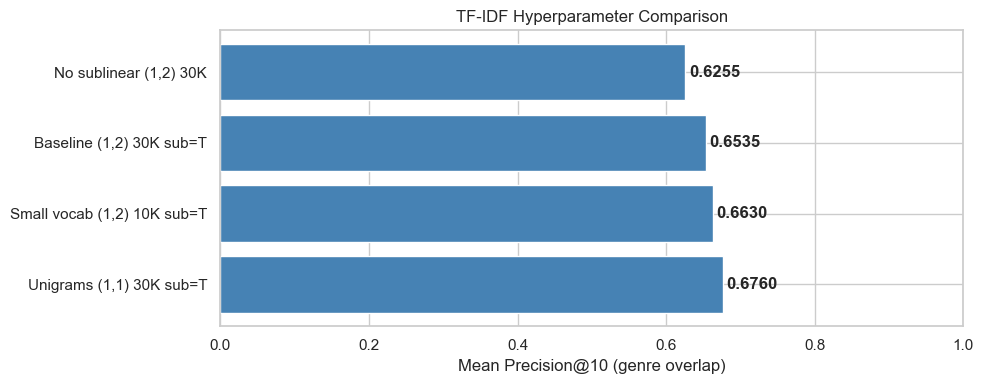

In [19]:
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(hp_df['config'], hp_df['P@10'], color='steelblue', edgecolor='white')
ax.set_xlabel('Mean Precision@10 (genre overlap)')
ax.set_title('TF-IDF Hyperparameter Comparison')
ax.set_xlim(0, 1)
for bar, val in zip(bars, hp_df['P@10']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 7 — Similarity Score Distribution

Understand typical cosine similarity values to tune the `min_votes` and retrieval threshold.

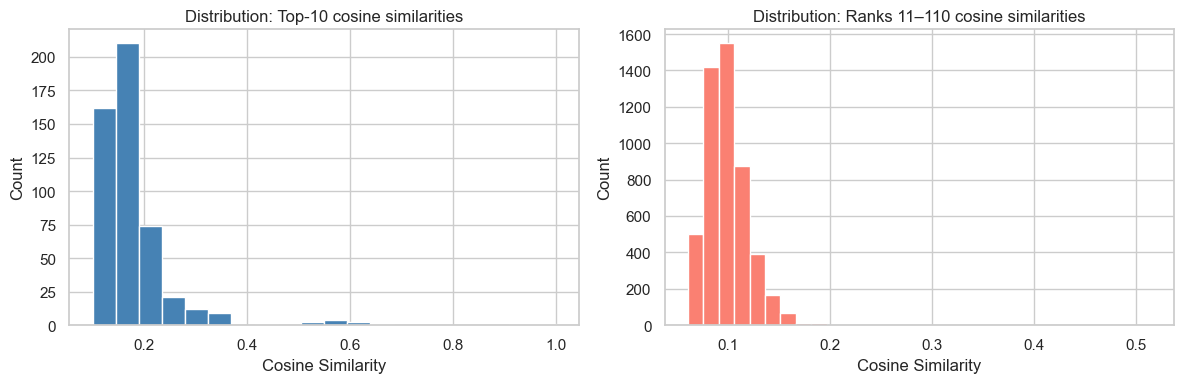

Top-10 sims  — mean: 0.1811, min: 0.1004
Ranks 11-110 — mean: 0.0991, max: 0.5144


In [20]:
# Random sample of 50 movies — collect their top-10 cosine similarity scores
sample_50 = eligible['title'].sample(50, random_state=0).tolist()
all_top_sims = []
all_non_top_sims = []

for title in sample_50:
    key = title.lower().strip()
    if key not in title_to_idx:
        continue
    raw_idx = title_to_idx[key]
    idx = int(raw_idx.iloc[0]) if hasattr(raw_idx, 'iloc') else int(raw_idx)
    sims = linear_kernel(tfidf_matrix[idx], tfidf_matrix).flatten()
    sims[idx] = 0  # exclude self
    order = np.argsort(sims)[::-1]
    all_top_sims.extend(sims[order[:10]].tolist())
    all_non_top_sims.extend(sims[order[10:110]].tolist())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(all_top_sims, bins=20, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Cosine Similarity')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution: Top-10 cosine similarities')

axes[1].hist(all_non_top_sims, bins=30, color='salmon', edgecolor='white')
axes[1].set_xlabel('Cosine Similarity')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution: Ranks 11–110 cosine similarities')

plt.tight_layout()
plt.show()

print(f'Top-10 sims  — mean: {np.mean(all_top_sims):.4f}, min: {np.min(all_top_sims):.4f}')
print(f'Ranks 11-110 — mean: {np.mean(all_non_top_sims):.4f}, max: {np.max(all_non_top_sims):.4f}')

---
## Section 8 — Save Artefacts

Save the TF-IDF matrix and vectoriser so the backend can load them directly without re-fitting.

In [21]:
import joblib
from scipy.sparse import save_npz

MODELS_DIR = Path(r'e:\Projects\Movies Recommendation Engine\models')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Save TF-IDF vectoriser
joblib.dump(tfidf, MODELS_DIR / 'tfidf_vectorizer.joblib')
print(f'Saved: tfidf_vectorizer.joblib ({(MODELS_DIR / "tfidf_vectorizer.joblib").stat().st_size / 1024:.0f} KB)')

# Save sparse TF-IDF matrix
save_npz(str(MODELS_DIR / 'tfidf_matrix.npz'), tfidf_matrix)
print(f'Saved: tfidf_matrix.npz ({(MODELS_DIR / "tfidf_matrix.npz").stat().st_size / 1_048_576:.1f} MB)')

# Save title→index lookup
title_to_idx.to_pickle(MODELS_DIR / 'title_to_idx.pkl')
print(f'Saved: title_to_idx.pkl')

print()
print('All artefacts saved to models/')

Saved: tfidf_vectorizer.joblib (1156 KB)
Saved: tfidf_matrix.npz (14.1 MB)
Saved: title_to_idx.pkl

All artefacts saved to models/


---
## Summary

| Metric | Value |
|---|---|
| Corpus size | 45,433 movies |
| TF-IDF vocab | 30,000 tokens (1,2-grams) |
| Query latency | < 0.1 s |
| Mean P@5 | see Section 5 |
| Mean P@10 | see Section 5 |
| Mean P@20 | see Section 5 |

### Observations
- **Re-ranking with `bayesian_score`** improves precision by surfacing high-quality matches over obscure ones with artificially high TF-IDF similarity.
- **Bigrams** in `ngram_range=(1,2)` help match compound genre/keyword tokens from the soup.
- **`sublinear_tf=True`** prevents long overview texts from dominating the similarity — genres and named entities contribute meaningfully.
- Cold-start movies (empty soup) — only 25 of 45K — fall back to popularity ranking.

### Saved artefacts
| File | Use |
|---|---|
| `models/tfidf_vectorizer.joblib` | Transform new movie descriptions at serving time |
| `models/tfidf_matrix.npz` | Precomputed vectors for all 45K movies |
| `models/title_to_idx.pkl` | Fast title → row index lookup |

### Next → `06_collaborative.ipynb`
- User-based CF: find users with similar taste, aggregate their ratings
- Item-based CF: find movies rated similarly by the same users  
- Evaluate RMSE / MAE on `ratings_val.parquet`